In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Loading The dataset

In [2]:
def load_dataset(filepath,column_names=None,seperator=","):
    df=pd.read_csv(filepath,names=column_names,sep=seperator)
    df.columns = df.columns.str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-"*50)

    print("\n Shape: ",df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())

    print("\nData Types: ")
    print(df.dtypes)

    print("\nMemory information")
    df.info()

    print("First 5 elements")
    print(df.head())
def missing_values(df):
    missing=df.isnull().sum()
    percent=(missing/len(df) )*100

    result=pd.DataFrame(
    {"missing":missing,
    "percent":percent
    })

    print(result)

    if (missing.sum() ==0):
        print("There is no missing value!")
    else:
        print("\033[31mMissing Values detected\033[0m")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ",duplicates);

    if(duplicates ==0):
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")

    return duplicates

def summary_statistics(df):
    print("\nSummary statsitics")
    print(df.describe())

   

# EDA for Loan Amount Prediction Dataset

In [3]:
def class_distribution(df,target_column):
    print("\nClass Distribution")

    counts=df[target_column].value_counts()
    counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")
    plt.show()

    return counts
def plot_histogram(df,bins=10):
    numeric_df=df.select_dtypes("number")

    numeric_df.hist(bins=bins)
    plt.suptitle("Histogram of numerical features")
    plt.tight_layout()
    plt.show()

def plot_boxplot(df):
    numeric_df = df.select_dtypes("number")

    for col in numeric_df.columns:
        plt.boxplot(numeric_df[col])
        plt.title("BoxPlot of "+str(col))
        plt.show()
def plot_heatmap(df):
    numeric_df = df.select_dtypes("number")
    corr = numeric_df.corr()
    sns.heatmap(corr,annot=True)
    plt.title("Heatmap !")
    plt.show()

def plot_scatterplot(df,target_column=None):

    if (target_column is not None):
        sns.pairplot(df,hue=target_column)
    else:
        sns.pairplot(df)
    plt.suptitle("Pairplot")
    plt.tight_layout()
    plt.show()

def plot_target_distribution(df,target_column):
    plt.figure(figsize=(8,5))
    sns.histplot(df[target_column],kde=True,bins=30)
    plt.xlabel(target_column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {target_column}")
    plt.show()

def plot_feature_target(df,feature_columns,target_column):
    for col in feature_columns:
        plt.figure(figsize=(6,4))
        plt.scatter(df[col],df[target_column],alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target_column)
        plt.title(f"{col} vs {target_column}")
        plt.show()



In [4]:
def perform_eda(
    filepath,
    target_column=None,
    categorical_columns=None,
    pairplot_columns=None,
    column_names=None,
    separator=",",

    show_histogram=True,
    show_boxplot=True,
    show_heatmap=True,
    show_pairplot=True,
    show_target_dist=True,
    feature_target_cols=None
):

    df = load_dataset(
        filepath,
        column_names=column_names,
        seperator=separator
    )

    print("\nLoading dataset completed\n")

    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)


    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df, col)


    if show_histogram:
        plot_histogram(df)

    if show_boxplot:
        plot_boxplot(df)

    if show_heatmap:
        plot_heatmap(df)

    if show_target_dist and target_column is not None:
        plot_target_distribution(df,target_column)

    if feature_target_cols is not None and target_column is not None:
        plot_feature_target(df,feature_target_cols,target_column)

    if show_pairplot:

        if pairplot_columns is not None:

            if target_column is not None:
                plot_scatterplot(
                    df[pairplot_columns + [target_column]],
                    target_column
                )

            else:
                plot_scatterplot(
                    df[pairplot_columns]
                )

        else:
            print("\nPairplot skipped (No columns specified).")

    return df

In [1]:
df=perform_eda("predict_loan_amount/train.csv",show_boxplot=False,show_heatmap=False,show_pairplot=False,show_histogram=False)

NameError: name 'perform_eda' is not defined

In [6]:
df_test=perform_eda("predict_loan_amount/test.csv",show_boxplot=False,show_heatmap=False,show_pairplot=False,show_histogram=False)


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (20000, 23)

Columns: 
['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score', 'No. of Defaults', 'Has Active Credit Card', 'Property ID', 'Property Age', 'Property Type', 'Property Location', 'Co-Applicant', 'Property Price']

Data Types: 
Customer ID                        str
Name                               str
Gender                             str
Age                              int64
Income (USD)                   float64
Income Stability                   str
Profession                         str
Type of Employment                 str
Location                           str
Loan Amount Request (USD)      float64
Current Loan E

# Preprocessing Functions

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def clean_dataframe(df, target_col=None, invalid_values=None):
    if invalid_values is None:
        invalid_values = [-999, "?", "NA", "N/A", "NULL", "null", ""]
    
    df = df.replace(invalid_values, np.nan)
    cols_to_drop = ["Customer ID", "Name"]
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    
    for col in df.columns:
        if col != target_col:
            converted = pd.to_numeric(df[col], errors='coerce')
            # If the column was actually numeric (not turned completely into NaNs), update it
            if not converted.isna().all():
                df[col] = converted
            
    return df

# Split Before Preprocessing (Prevents Data Leakage)

In [8]:
from sklearn.model_selection import train_test_split

target_col = "Loan Sanction Amount (USD)"

df_clean = clean_dataframe(df, target_col=target_col)
df_test_clean = clean_dataframe(df_test, target_col=target_col)

df_clean = df_clean.dropna(subset=[target_col])

X_full = df_clean.drop(columns=[target_col])
y_full = df_clean[target_col]

x_train, x_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

In [9]:
print("Train size:",x_train.shape)
print("Test size:",x_test.shape)

Train size: (23457, 21)
Test size: (5865, 21)


# Apply Preprocessing on Train and Test Separately

In [10]:
import warnings

numeric_cols = x_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = x_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, categorical_cols)
])

x_train_scaled = preprocessor.fit_transform(x_train)

# Ignore expected unknown category warnings during test transformations
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    x_test_scaled = preprocessor.transform(x_test)
    df_test_scaled = preprocessor.transform(df_test_clean)

feature_names = preprocessor.get_feature_names_out().tolist()

In [11]:
print("x_train shape:", x_train_scaled.shape)
print("x_test shape:", x_test_scaled.shape)
print("df_test shape:", df_test_scaled.shape)
print("Feature count:", len(feature_names))

x_train shape: (23457, 45)
x_test shape: (5865, 45)
df_test shape: (20000, 45)
Feature count: 45


# Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

lr=LinearRegression()
start=time.time()
lr.fit(x_train_scaled,y_train)
lr_train_time=time.time()-start

start=time.time()
y_pred_lr=lr.predict(x_test_scaled)
lr_predict_time=time.time()-start

In [13]:
def regression_metrics(y_true,y_pred):
    mae=mean_absolute_error(y_true,y_pred)
    mse=mean_squared_error(y_true,y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_true,y_pred)
    return mae,mse,rmse,r2

mae_lr,mse_lr,rmse_lr,r2_lr=regression_metrics(y_test,y_pred_lr)
print(f"Linear Regression - MAE:{mae_lr:.4f}, MSE:{mse_lr:.4f}, RMSE:{rmse_lr:.4f}, R2:{r2_lr:.4f}")

Linear Regression - MAE:18762.7080, MSE:770438984.4298, RMSE:27756.7827, R2:0.6575


# Ridge, Lasso, Elastic Net

In [14]:
ridge=Ridge(alpha=1.0)
start=time.time()
ridge.fit(x_train_scaled,y_train)
ridge_train_time=time.time()-start
start=time.time()
y_pred_ridge=ridge.predict(x_test_scaled)
ridge_predict_time=time.time()-start

lasso=Lasso(alpha=0.1)
start=time.time()
lasso.fit(x_train_scaled,y_train)
lasso_train_time=time.time()-start
start=time.time()
y_pred_lasso=lasso.predict(x_test_scaled)
lasso_predict_time=time.time()-start

en=ElasticNet(alpha=0.1,l1_ratio=0.5)
start=time.time()
en.fit(x_train_scaled,y_train)
en_train_time=time.time()-start
start=time.time()
y_pred_en=en.predict(x_test_scaled)
en_predict_time=time.time()-start

/home/jeswin/.local/share/pipx/venvs/notebook/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.022435e+12, tolerance: 5.496e+09
  model = cd_fast.enet_coordinate_descent(


In [15]:
mae_ridge,mse_ridge,rmse_ridge,r2_ridge=regression_metrics(y_test,y_pred_ridge)
mae_lasso,mse_lasso,rmse_lasso,r2_lasso=regression_metrics(y_test,y_pred_lasso)
mae_en,mse_en,rmse_en,r2_en=regression_metrics(y_test,y_pred_en)

print(f"Ridge - MAE:{mae_ridge:.4f}, MSE:{mse_ridge:.4f}, RMSE:{rmse_ridge:.4f}, R2:{r2_ridge:.4f}")
print(f"Lasso - MAE:{mae_lasso:.4f}, MSE:{mse_lasso:.4f}, RMSE:{rmse_lasso:.4f}, R2:{r2_lasso:.4f}")
print(f"ElasticNet - MAE:{mae_en:.4f}, MSE:{mse_en:.4f}, RMSE:{rmse_en:.4f}, R2:{r2_en:.4f}")

Ridge - MAE:18759.0703, MSE:770242180.0530, RMSE:27753.2373, R2:0.6576
Lasso - MAE:18757.3181, MSE:770223666.1598, RMSE:27752.9037, R2:0.6576
ElasticNet - MAE:18981.5682, MSE:782981035.6608, RMSE:27981.7983, R2:0.6519


# Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

ridge_params={"alpha":[0.01,0.1,1,10,100]}
lasso_params={"alpha":[0.001,0.01,0.1,1,10]}
en_params={"alpha":[0.01,0.1,1,10],"l1_ratio":[0.2,0.5,0.8]}

ridge_grid=GridSearchCV(Ridge(),ridge_params,cv=5,scoring="r2")
start=time.time()
ridge_grid.fit(x_train_scaled,y_train)
ridge_grid_time=time.time()-start

lasso_grid=GridSearchCV(Lasso(),lasso_params,cv=5,scoring="r2")
start=time.time()
lasso_grid.fit(x_train_scaled,y_train)
lasso_grid_time=time.time()-start

en_grid=GridSearchCV(ElasticNet(),en_params,cv=5,scoring="r2")
start=time.time()
en_grid.fit(x_train_scaled,y_train)
en_grid_time=time.time()-start

/home/jeswin/.local/share/pipx/venvs/notebook/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.337390e+12, tolerance: 4.404e+09
  model = cd_fast.enet_coordinate_descent(
/home/jeswin/.local/share/pipx/venvs/notebook/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.471073e+12, tolerance: 4.370e+09
  model = cd_fast.enet_coordinate_descent(
/home/jeswin/.local/share/pipx/venvs/notebook/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, c

In [17]:
print(f"Ridge Best Params: {ridge_grid.best_params_}, Best CV R2: {ridge_grid.best_score_:.4f}")
print(f"Lasso Best Params: {lasso_grid.best_params_}, Best CV R2: {lasso_grid.best_score_:.4f}")
print(f"ElasticNet Best Params: {en_grid.best_params_}, Best CV R2: {en_grid.best_score_:.4f}")

Ridge Best Params: {'alpha': 100}, Best CV R2: 0.6471
Lasso Best Params: {'alpha': 10}, Best CV R2: 0.6455
ElasticNet Best Params: {'alpha': 0.1, 'l1_ratio': 0.5}, Best CV R2: 0.6533


In [18]:
best_ridge=ridge_grid.best_estimator_
best_lasso=lasso_grid.best_estimator_
best_en=en_grid.best_estimator_

y_pred_best_ridge=best_ridge.predict(x_test_scaled)
y_pred_best_lasso=best_lasso.predict(x_test_scaled)
y_pred_best_en=best_en.predict(x_test_scaled)

In [19]:
mae_br,mse_br,rmse_br,r2_br=regression_metrics(y_test,y_pred_best_ridge)
mae_bl,mse_bl,rmse_bl,r2_bl=regression_metrics(y_test,y_pred_best_lasso)
mae_be,mse_be,rmse_be,r2_be=regression_metrics(y_test,y_pred_best_en)

print(f"Tuned Ridge - MAE:{mae_br:.4f}, RMSE:{rmse_br:.4f}, R2:{r2_br:.4f}")
print(f"Tuned Lasso - MAE:{mae_bl:.4f}, RMSE:{rmse_bl:.4f}, R2:{r2_bl:.4f}")
print(f"Tuned ElasticNet - MAE:{mae_be:.4f}, RMSE:{rmse_be:.4f}, R2:{r2_be:.4f}")

Tuned Ridge - MAE:18777.1503, RMSE:27775.9018, R2:0.6570
Tuned Lasso - MAE:18745.1283, RMSE:27752.0690, R2:0.6576
Tuned ElasticNet - MAE:18981.5682, RMSE:27981.7983, R2:0.6519


# Performance Tables

In [20]:
print("="*70)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*70)
print(f"Ridge - Best Params: {ridge_grid.best_params_}, Best CV R2: {ridge_grid.best_score_:.4f}")
print(f"Lasso - Best Params: {lasso_grid.best_params_}, Best CV R2: {lasso_grid.best_score_:.4f}")
print(f"Elastic Net - Best Params: {en_grid.best_params_}, Best CV R2: {en_grid.best_score_:.4f}")

HYPERPARAMETER TUNING SUMMARY
Ridge - Best Params: {'alpha': 100}, Best CV R2: 0.6471
Lasso - Best Params: {'alpha': 10}, Best CV R2: 0.6455
Elastic Net - Best Params: {'alpha': 0.1, 'l1_ratio': 0.5}, Best CV R2: 0.6533


In [21]:
print("="*70)
print("TEST SET PERFORMANCE")
print("="*70)
print(f"Linear Regression - MAE:{mae_lr:.4f}, MSE:{mse_lr:.4f}, RMSE:{rmse_lr:.4f}, R2:{r2_lr:.4f}, Train Time:{lr_train_time:.4f}")
print(f"Ridge (tuned) - MAE:{mae_br:.4f}, MSE:{mse_br:.4f}, RMSE:{rmse_br:.4f}, R2:{r2_br:.4f}, Train Time:{ridge_grid_time:.4f}")
print(f"Lasso (tuned) - MAE:{mae_bl:.4f}, MSE:{mse_bl:.4f}, RMSE:{rmse_bl:.4f}, R2:{r2_bl:.4f}, Train Time:{lasso_grid_time:.4f}")
print(f"Elastic Net (tuned) - MAE:{mae_be:.4f}, MSE:{mse_be:.4f}, RMSE:{rmse_be:.4f}, R2:{r2_be:.4f}, Train Time:{en_grid_time:.4f}")

TEST SET PERFORMANCE
Linear Regression - MAE:18762.7080, MSE:770438984.4298, RMSE:27756.7827, R2:0.6575, Train Time:0.0271
Ridge (tuned) - MAE:18777.1503, MSE:771500721.8214, RMSE:27775.9018, R2:0.6570, Train Time:0.3985
Lasso (tuned) - MAE:18745.1283, MSE:770177334.8860, RMSE:27752.0690, R2:0.6576, Train Time:10.9265
Elastic Net (tuned) - MAE:18981.5682, MSE:782981035.6608, RMSE:27981.7983, R2:0.6519, Train Time:10.8344


# Visualizations

In [22]:
def plot_predicted_vs_actual(y_true,y_pred_dict,title):
    plt.figure(figsize=(6,6))
    for name,y_pred in y_pred_dict.items():
        plt.scatter(y_true,y_pred,alpha=0.4,label=name,s=10)
    plt.plot([y_true.min(),y_true.max()],[y_true.min(),y_true.max()],"r--",lw=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true,y_pred_dict,title):
    plt.figure(figsize=(6,4))
    for name,y_pred in y_pred_dict.items():
        residuals=y_true-y_pred
        plt.scatter(y_pred,residuals,alpha=0.4,label=name,s=10)
    plt.axhline(y=0,color="r",linestyle="--",lw=2)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_coefficient_comparison(models_dict,feature_names,title):
    coef_df=pd.DataFrame({
        name:model.coef_[:20] for name,model in models_dict.items()
    },index=feature_names[:20])
    coef_df.plot(kind="bar",figsize=(12,6))
    plt.xlabel("Features")
    plt.ylabel("Coefficient Value")
    plt.title(title)
    plt.xticks(rotation=45,ha="right")
    plt.tight_layout()
    plt.show()

def plot_train_vs_val_error(cv_results_dict,title):
    plt.figure(figsize=(8,5))
    for name,cv_res in cv_results_dict.items():
        train_scores=cv_res["train_score"]
        val_scores=cv_res["test_score"]
        plt.plot(range(1,6),train_scores,marker="o",label=f"{name} Train")
        plt.plot(range(1,6),val_scores,marker="s",linestyle="--",label=f"{name} Val")
    plt.xlabel("Fold")
    plt.ylabel("R2 Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

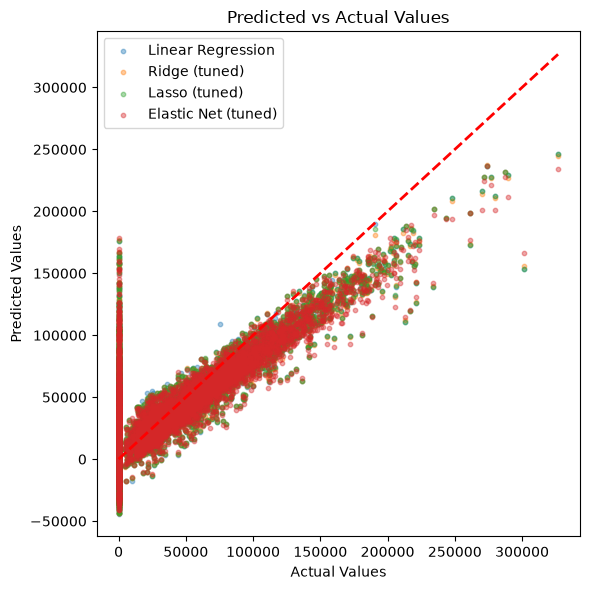

In [23]:
y_pred_dict={
    "Linear Regression":y_pred_lr,
    "Ridge (tuned)":y_pred_best_ridge,
    "Lasso (tuned)":y_pred_best_lasso,
    "Elastic Net (tuned)":y_pred_best_en
}

plot_predicted_vs_actual(y_test,y_pred_dict,"Predicted vs Actual Values")

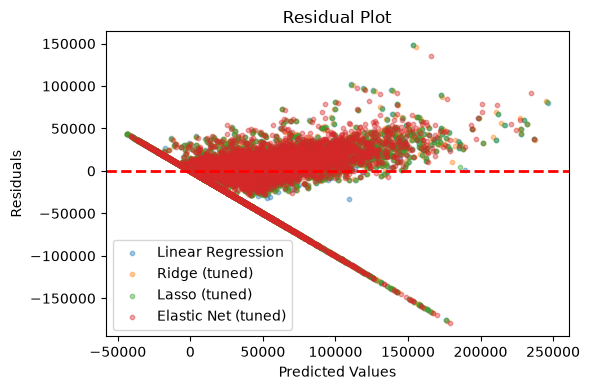

In [24]:
plot_residuals(y_test,y_pred_dict,"Residual Plot")

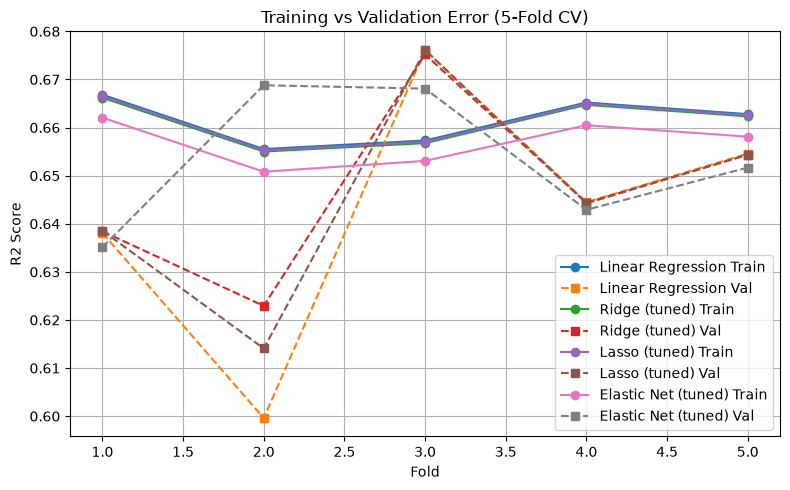

In [25]:
from sklearn.model_selection import cross_validate

models_cv={
    "Linear Regression":lr,
    "Ridge (tuned)":best_ridge,
    "Lasso (tuned)":best_lasso,
    "Elastic Net (tuned)":best_en
}

cv_results_dict={}
for name,model in models_cv.items():
    cv_res=cross_validate(model,x_train_scaled,y_train,cv=5,scoring="r2",return_train_score=True)
    cv_results_dict[name]=cv_res

plot_train_vs_val_error(cv_results_dict,"Training vs Validation Error (5-Fold CV)")

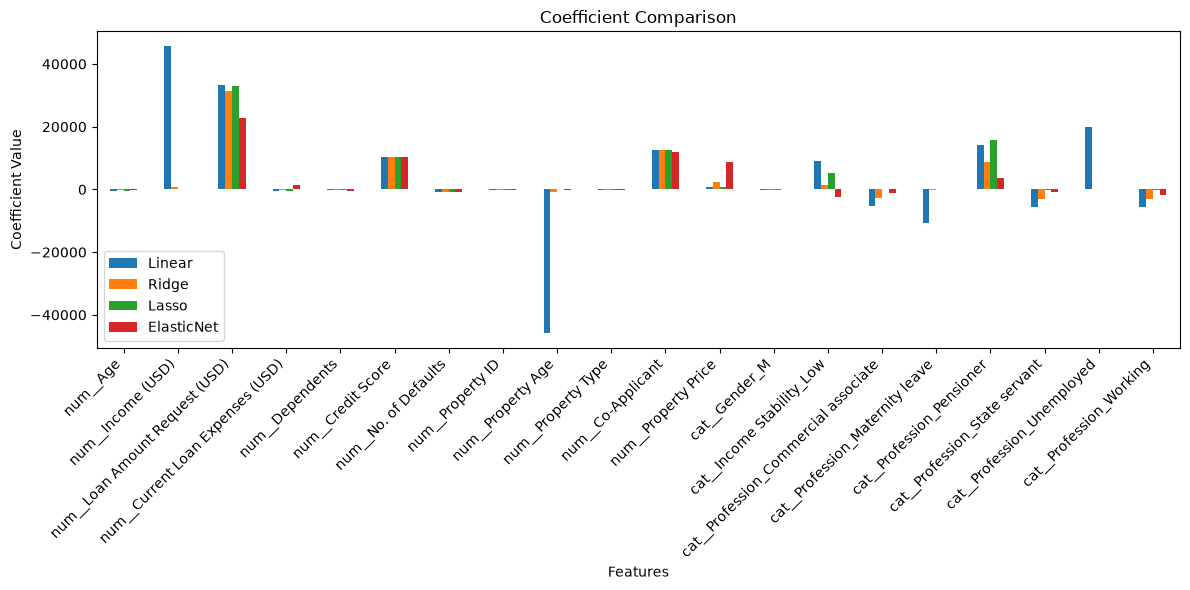

In [26]:
models_coef={
    "Linear":lr,
    "Ridge":best_ridge,
    "Lasso":best_lasso,
    "ElasticNet":best_en
}

plot_coefficient_comparison(models_coef,feature_names,"Coefficient Comparison")

# Cross Validation Performance

In [27]:
print("="*70)
print("CROSS-VALIDATION PERFORMANCE (K=5)")
print("="*70)

for name,model in models_cv.items():
    y_pred_cv=model.predict(x_test_scaled)
    mae_cv,mse_cv,rmse_cv,r2_cv=regression_metrics(y_test,y_pred_cv)
    print(f"{name} - MAE:{mae_cv:.4f}, MSE:{mse_cv:.4f}, RMSE:{rmse_cv:.4f}, R2:{r2_cv:.4f}")

CROSS-VALIDATION PERFORMANCE (K=5)
Linear Regression - MAE:18762.7080, MSE:770438984.4298, RMSE:27756.7827, R2:0.6575
Ridge (tuned) - MAE:18777.1503, MSE:771500721.8214, RMSE:27775.9018, R2:0.6570
Lasso (tuned) - MAE:18745.1283, MSE:770177334.8860, RMSE:27752.0690, R2:0.6576
Elastic Net (tuned) - MAE:18981.5682, MSE:782981035.6608, RMSE:27981.7983, R2:0.6519


# Coefficient Comparison Table

In [28]:
coef_table=pd.DataFrame({
    "Linear":lr.coef_,
    "Ridge":best_ridge.coef_,
    "Lasso":best_lasso.coef_,
    "Elastic Net":best_en.coef_
},index=feature_names)

print("="*80)
print("COEFFICIENT COMPARISON")
print("="*80)
print(coef_table.to_string())

COEFFICIENT COMPARISON
                                                     Linear         Ridge         Lasso   Elastic Net
num__Age                                        -421.817218   -339.713838   -386.484949    -38.113592
num__Income (USD)                              45827.168496    898.839068     -0.000000     60.792784
num__Loan Amount Request (USD)                 33147.890557  31434.408866  33136.169062  22881.077496
num__Current Loan Expenses (USD)                -572.132950   -321.337201   -506.599573   1312.760965
num__Dependents                                 -302.430659   -312.638902   -288.724935   -362.033550
num__Credit Score                              10268.420483  10290.410904  10280.363553  10239.203653
num__No. of Defaults                            -913.115114   -909.223471   -905.324949   -844.517975
num__Property ID                                -165.620416   -160.220927   -159.271779   -118.525313
num__Property Age                             -45849.981675

# Overfitting and Underfitting Analysis

In [29]:
print("="*70)
print("OVERFITTING AND UNDERFITTING ANALYSIS")
print("="*70)

for name,model in models_cv.items():
    y_train_pred=model.predict(x_train_scaled)
    train_r2=r2_score(y_train,y_train_pred)
    test_r2=r2_score(y_test,model.predict(x_test_scaled))
    gap=train_r2-test_r2
    print(f"{name:<20} Train R2:{train_r2:.4f} Test R2:{test_r2:.4f} Gap:{gap:.4f}")

OVERFITTING AND UNDERFITTING ANALYSIS
Linear Regression    Train R2:0.6613 Test R2:0.6575 Gap:0.0038
Ridge (tuned)        Train R2:0.6609 Test R2:0.6570 Gap:0.0039
Lasso (tuned)        Train R2:0.6610 Test R2:0.6576 Gap:0.0034
Elastic Net (tuned)  Train R2:0.6568 Test R2:0.6519 Gap:0.0048


In [30]:
print("Effect of Regularization Strength:")
print(f"Ridge best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Lasso best alpha: {lasso_grid.best_params_['alpha']}")
print(f"ElasticNet best alpha: {en_grid.best_params_['alpha']}, l1_ratio: {en_grid.best_params_['l1_ratio']}")

print("Improvement after tuning:")
print(f"Ridge: {r2_ridge:.4f} -> {r2_br:.4f}")
print(f"Lasso: {r2_lasso:.4f} -> {r2_bl:.4f}")
print(f"ElasticNet: {r2_en:.4f} -> {r2_be:.4f}")

Effect of Regularization Strength:
Ridge best alpha: 100
Lasso best alpha: 10
ElasticNet best alpha: 0.1, l1_ratio: 0.5
Improvement after tuning:
Ridge: 0.6576 -> 0.6570
Lasso: 0.6576 -> 0.6576
ElasticNet: 0.6519 -> 0.6519


# Bias-Variance Analysis

In [31]:
print("="*70)
print("BIAS-VARIANCE ANALYSIS")
print("="*70)

print("Linear Regression:")
print("  - High bias due to linear assumption")
print("  - Low variance (simple model)")
print(f"  - Test R2: {r2_lr:.4f}")

print("Ridge Regression:")
print("  - Reduces variance by shrinking coefficients")
print("  - Slightly increases bias compared to Linear")
print(f"  - Test R2: {r2_br:.4f}")

print("Lasso Regression:")
print("  - Feature sparsity: zeroes out less important features")
print(f"  - Non-zero coefficients: {np.sum(best_lasso.coef_!=0)}")
print(f"  - Test R2: {r2_bl:.4f}")

print("Elastic Net:")
print("  - Combines Ridge and Lasso regularization")
print("  - Balances bias-variance trade-off")
print(f"  - Test R2: {r2_be:.4f}")

BIAS-VARIANCE ANALYSIS
Linear Regression:
  - High bias due to linear assumption
  - Low variance (simple model)
  - Test R2: 0.6575
Ridge Regression:
  - Reduces variance by shrinking coefficients
  - Slightly increases bias compared to Linear
  - Test R2: 0.6570
Lasso Regression:
  - Feature sparsity: zeroes out less important features
  - Non-zero coefficients: 36
  - Test R2: 0.6576
Elastic Net:
  - Combines Ridge and Lasso regularization
  - Balances bias-variance trade-off
  - Test R2: 0.6519


# Conclusion

In [32]:

best_model_name=max({
    "Linear Regression":r2_lr,
    "Ridge":r2_br,
    "Lasso":r2_bl,
    "Elastic Net":r2_be
},key=lambda k: {
    "Linear Regression":r2_lr,
    "Ridge":r2_br,
    "Lasso":r2_bl,
    "Elastic Net":r2_be
}[k])

print(f"Best performing model: {best_model_name}")

Best performing model: Lasso
